In [31]:
!pip install gensim

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 4.5.1 Text Preprocessing, Tokenization, and Sequence Padding
In this section, we load the dataset and perform text cleaning to prepare it for tokenization.

In [33]:
import pandas as pd
import re
import string

# Load the dataset with latin-1 encoding to avoid UnicodeDecodeError
file_path = '/content/drive/MyDrive/9.Spam vs Ham Sms Dataset/spamvsham.csv'
df = pd.read_csv(file_path, encoding='latin-1')

# Display initial data
print("Dataset Shape:", df.shape)
display(df.head())

# Identify columns (SMS datasets usually have 'v1' as label and 'v2' as message)
# We will rename them for clarity if they follow that common pattern
if 'v1' in df.columns and 'v2' in df.columns:
    df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})

text_col = 'text' if 'text' in df.columns else df.columns[1]
label_col = 'label' if 'label' in df.columns else df.columns[0]

Dataset Shape: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [34]:
import pandas as pd
import re
import string

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return " ".join(text.split())

# Map columns and apply initial cleaning
text_col = 'text' if 'text' in df.columns else df.columns[1]
df['cleaned_text'] = df[text_col].apply(clean_text)
display(df.head())

,label,text,cleaned_text
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


In [35]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Dictionary for handling contractions
contractions_dict = {"don't": "do not", "can't": "cannot", "i'm": "i am", "it's": "it is", "he's": "he is", "she's": "she is", "that's": "that is", "we're": "we are", "they're": "they are"}

def advanced_clean(text):
    # Handle contractions
    for word in text.split():
        if word in contractions_dict:
            text = text.replace(word, contractions_dict[word])

    # Lemmatize and remove stopwords
    words = [lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words]
    return " ".join(words)

# Check if column exists before applying
if 'cleaned_text' in df.columns:
    df['cleaned_text'] = df['cleaned_text'].apply(advanced_clean)
    display(df[['text', 'cleaned_text']].head())
else:
    print("Error: 'cleaned_text' column not found. Please run the previous cell.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,text,cleaned_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


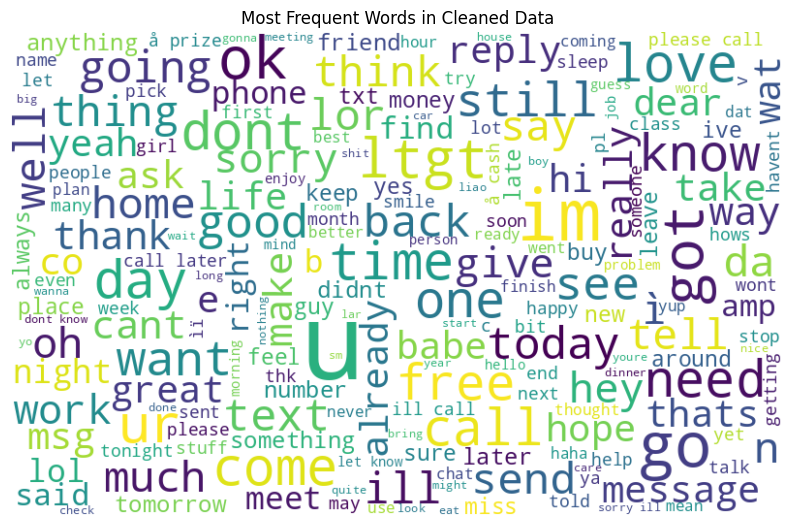

In [36]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Ensure the column exists before generating the word cloud
if 'cleaned_text' in df.columns:
    all_words = ' '.join([text for text in df['cleaned_text']])
    wordcloud = WordCloud(width=800, height=500, random_state=21, max_font_size=110, background_color='white').generate(all_words)

    plt.figure(figsize=(10, 7))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis('off')
    plt.title('Most Frequent Words in Cleaned Data')
    plt.show()
else:
    print("Please run the cleaning cells first.")

### Tokenization and Padding
In this section, we split the data and convert the text into padded sequences for the RNN/LSTM models.

In [37]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# 1. Split the dataset (80% training, 20% testing)
X = df['cleaned_text']
# Convert labels to numeric: spam=1, ham=0
y = df['label'].map({'spam': 1, 'ham': 0}).values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Keras Tokenizer
max_words = 10000
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_raw)

X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_test_seq = tokenizer.texts_to_sequences(X_test_raw)

# 3. Percentile-based Padding
lengths = [len(x) for x in X_train_seq]
max_pad_length = int(np.percentile(lengths, 95))
print(f'Padding length (95th percentile): {max_pad_length}')

X_train_pad = pad_sequences(X_train_seq, maxlen=max_pad_length, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_pad_length, padding='post', truncating='post')

print('Shape of training tensor:', X_train_pad.shape)
print('Shape of testing tensor:', X_test_pad.shape)

Padding length (95th percentile): 20
Shape of training tensor: (4457, 20)
Shape of testing tensor: (1115, 20)


### 4.5.2 & 4.5.3 Model Building, Training, and Evaluation
We will now construct the Simple RNN and LSTM models, then train them using early stopping to prevent overfitting.

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

vocab_size = 10000
embedding_dim = 64
input_length = max_pad_length

# Model 1: Simple RNN with trainable Embedding layer
model1 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=input_length),
    SimpleRNN(64),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Model 2: LSTM with trainable Embedding layer
model2 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=input_length),
    LSTM(64),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks for early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Training Model 1 (Simple RNN)...")
history1 = model1.fit(X_train_pad, y_train, epochs=10, batch_size=32, validation_split=0.2, callbacks=[early_stop], verbose=1)

print("\nTraining Model 2 (LSTM)...")
history2 = model2.fit(X_train_pad, y_train, epochs=10, batch_size=32, validation_split=0.2, callbacks=[early_stop], verbose=1)

Training Model 1 (Simple RNN)...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.9324 - loss: 0.2096 - val_accuracy: 0.9720 - val_loss: 0.1099
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9874 - loss: 0.0579 - val_accuracy: 0.9731 - val_loss: 0.0825
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9941 - loss: 0.0274 - val_accuracy: 0.9720 - val_loss: 0.0939
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.9966 - loss: 0.0183 - val_accuracy: 0.9731 - val_loss: 0.1157
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9986 - loss: 0.0084 - val_accuracy: 0.9675 - val_loss: 0.1289

Training Model 2 (LSTM)...
Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.9296 - loss: 0.2218 - val_accuracy: 0.9709 - val_loss: 0.0958
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9891 - loss: 0.0436 - val_accuracy: 0.9765 - val_loss: 0.0964
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9964 - loss:

### 4.5.2 Model 3: LSTM with Pretrained Word2Vec Embeddings
We train a Word2Vec model on our corpus to create an embedding matrix, which is then used as static weights for our third model.

In [39]:
from gensim.models import Word2Vec
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Prepare tokens for Word2Vec training
sentences = [text.split() for text in X_train_raw]

# Train Word2Vec model
w2v_model = Word2Vec(sentences, vector_size=64, window=5, min_count=1, workers=4)

# Create embedding matrix
vocab_size_w2v = min(max_words, len(tokenizer.word_index) + 1)
embedding_matrix = np.zeros((vocab_size_w2v, 64))

for word, i in tokenizer.word_index.items():
    if i < vocab_size_w2v:
        if word in w2v_model.wv:
            embedding_matrix[i] = w2v_model.wv[word]

# Model 3: LSTM using Word2Vec embeddings
model3 = Sequential([
    Embedding(input_dim=vocab_size_w2v, output_dim=64, weights=[embedding_matrix], trainable=False),
    LSTM(64),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print('Training Model 3 (LSTM with Word2Vec)...')
history3 = model3.fit(X_train_pad, y_train, epochs=10, batch_size=32, validation_split=0.2, callbacks=[early_stop], verbose=1)

Training Model 3 (LSTM with Word2Vec)...
Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8600 - loss: 0.3693 - val_accuracy: 0.8621 - val_loss: 0.3007
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8710 - loss: 0.2961 - val_accuracy: 0.8610 - val_loss: 0.3020
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8670 - loss: 0.2948 - val_accuracy: 0.8655 - val_loss: 0.2994


### 4.5.3 Model Training and Evaluation
Visualization of training history and final evaluation using Confusion Matrices and Classification Reports.

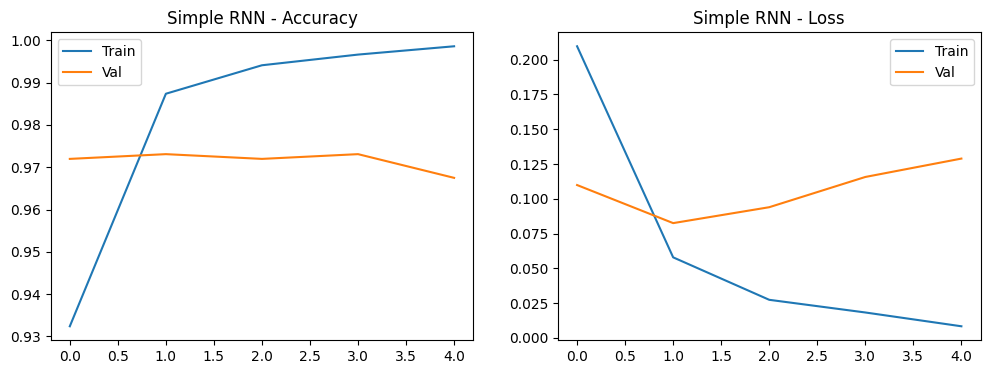

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

--- Simple RNN Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.98      0.89      0.93       150

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



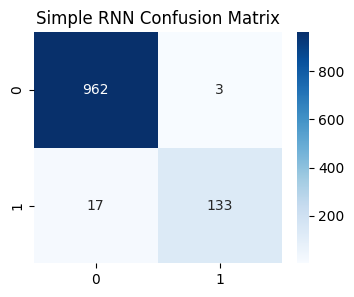

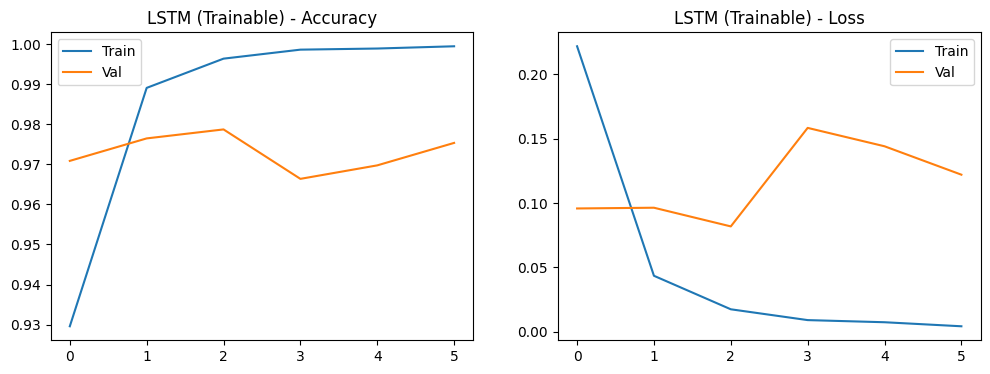

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

--- LSTM (Trainable) Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.99      0.87      0.93       150

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



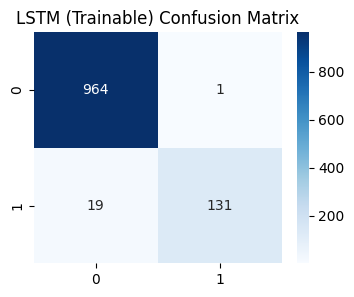

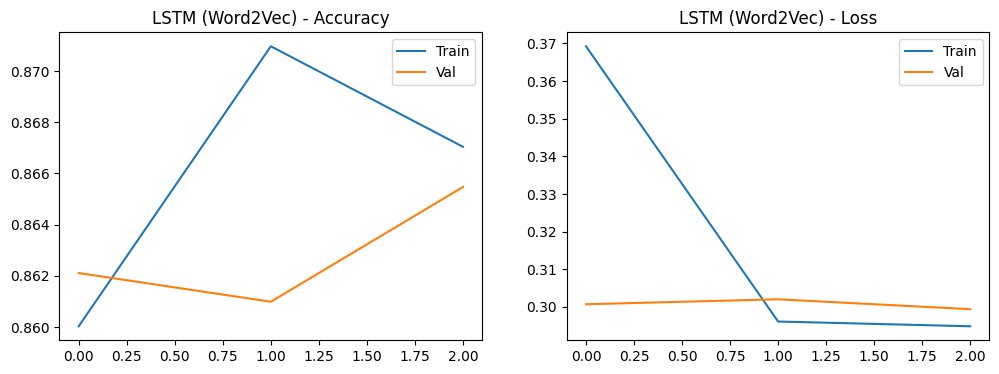

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

--- LSTM (Word2Vec) Classification Report ---
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       965
           1       0.00      0.00      0.00       150

    accuracy                           0.87      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.75      0.87      0.80      1115



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


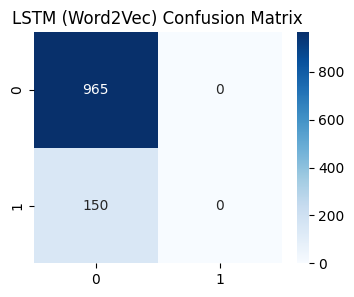

In [40]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title(f'{title} - Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.show()

def evaluate_model(model, name):
    predictions = (model.predict(X_test_pad) > 0.5).astype('int32')
    print(f'\n--- {name} Classification Report ---')
    print(classification_report(y_test, predictions))
    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.show()

plot_history(history1, 'Simple RNN')
evaluate_model(model1, 'Simple RNN')

plot_history(history2, 'LSTM (Trainable)')
evaluate_model(model2, 'LSTM (Trainable)')

if 'history3' in locals():
    plot_history(history3, 'LSTM (Word2Vec)')
    evaluate_model(model3, 'LSTM (Word2Vec)')

### 4.5.4 Error Analysis
In this section, we analyze the misclassified instances from our best-performing model (LSTM) to identify patterns such as slang or context that the model might have missed.

In [41]:
import pandas as pd

# Get predictions for Model 2 (LSTM)
y_pred_lstm = (model2.predict(X_test_pad) > 0.5).astype('int32').flatten()

# Create a dataframe for analysis
error_analysis_df = pd.DataFrame({
    'Original Message': df.loc[X_test_raw.index, 'text'],
    'Actual': y_test,
    'Predicted': y_pred_lstm
})

# Filter misclassified examples
misclassified = error_analysis_df[error_analysis_df['Actual'] != error_analysis_df['Predicted']]

print(f"Total misclassified examples in test set: {len(misclassified)}")
print("\n--- Sample Misclassified Examples (0=Ham, 1=Spam) ---")
display(misclassified.head(10))

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Total misclassified examples in test set: 20

--- Sample Misclassified Examples (0=Ham, 1=Spam) ---


,Original Message,Actual,Predicted
683,Hi I'm sue. I am 20 years old and work as a la...,1,0
4071,Loans for any purpose even if you have Bad Cre...,1,0
2312,tddnewsletter@emc1.co.uk (More games from TheD...,1,0
3979,ringtoneking 84484,1,0
712,08714712388 between 10am-7pm Cost 10p,1,0
730,Email AlertFrom: Jeri StewartSize: 2KBSubject:...,1,0
2662,Hello darling how are you today? I would love ...,1,0
4904,Warner Village 83118 C Colin Farrell in SWAT t...,1,0
4296,thesmszone.com lets you send free anonymous an...,1,0
787,Ever thought about living a good life with a p...,1,0


### 4.5.5 GUI Implementation using Gradio
We will now use `Gradio` to create a simple web-based interface for real-time predictions.

In [42]:
!pip install -q gradio
import gradio as gr

def predict_spam(message):
    # 1. Clean
    cleaned = clean_text(message)
    cleaned = advanced_clean(cleaned)
    # 2. Tokenize & Pad
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_pad_length, padding='post', truncating='post')
    # 3. Predict
    prediction = model2.predict(padded)[0][0]
    label = "Spam" if prediction > 0.5 else "Ham"
    confidence = prediction if prediction > 0.5 else 1 - prediction
    return f"Prediction: {label} (Confidence: {confidence:.2%})"

# Create Gradio Interface
interface = gr.Interface(
    fn=predict_spam,
    inputs=gr.Textbox(lines=2, placeholder="Enter SMS here..."),
    outputs="text",
    title="SMS Spam Detector",
    description="Enter a message to see if the LSTM model classifies it as Spam or Ham."
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://30972dc5ad2d0afb0d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### 4.5.4 Error Analysis
In this section, we analyze the misclassified instances from our best-performing model (LSTM) to identify patterns and potential areas for improvement.

In [43]:
import pandas as pd

# Get predictions for Model 2 (LSTM)
y_pred_lstm = (model2.predict(X_test_pad) > 0.5).astype('int32').flatten()

# Create a dataframe for analysis
error_analysis_df = pd.DataFrame({
    'Original Message': df.loc[X_test_raw.index, 'text'],
    'Actual': y_test,
    'Predicted': y_pred_lstm
})

# Filter misclassified examples
misclassified = error_analysis_df[error_analysis_df['Actual'] != error_analysis_df['Predicted']]

print(f"Total misclassified examples in test set: {len(misclassified)}")
print("\n--- Sample Misclassified Examples (0=Ham, 1=Spam) ---")
display(misclassified.head(10))

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Total misclassified examples in test set: 20

--- Sample Misclassified Examples (0=Ham, 1=Spam) ---


,Original Message,Actual,Predicted
683,Hi I'm sue. I am 20 years old and work as a la...,1,0
4071,Loans for any purpose even if you have Bad Cre...,1,0
2312,tddnewsletter@emc1.co.uk (More games from TheD...,1,0
3979,ringtoneking 84484,1,0
712,08714712388 between 10am-7pm Cost 10p,1,0
730,Email AlertFrom: Jeri StewartSize: 2KBSubject:...,1,0
2662,Hello darling how are you today? I would love ...,1,0
4904,Warner Village 83118 C Colin Farrell in SWAT t...,1,0
4296,thesmszone.com lets you send free anonymous an...,1,0
787,Ever thought about living a good life with a p...,1,0


### 4.5.5 GUI Implementation using Gradio
We will use `Gradio` to create a simple web-based interface where you can input any SMS message and get an instant prediction from our trained LSTM model.

In [44]:
!pip install -q gradio
import gradio as gr

def predict_spam(message):
    # 1. Clean
    cleaned = clean_text(message)
    cleaned = advanced_clean(cleaned)
    # 2. Tokenize & Pad
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_pad_length, padding='post', truncating='post')
    # 3. Predict
    prediction = model2.predict(padded)[0][0]
    label = "Spam" if prediction > 0.5 else "Ham"
    confidence = prediction if prediction > 0.5 else 1 - prediction
    return f"Prediction: {label} (Confidence: {confidence:.2%})"

# Create Gradio Interface
interface = gr.Interface(
    fn=predict_spam,
    inputs=gr.Textbox(lines=2, placeholder="Enter SMS here..."),
    outputs="text",
    title="SMS Spam Detector",
    description="Enter a message to see if the LSTM model classifies it as Spam or Ham."
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e2a4733a5a480cfe59.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### 4.5.4 Error Analysis
In this section, we analyze the misclassified instances from our best-performing model (LSTM) to identify patterns and potential areas for improvement.

In [45]:
import pandas as pd

# Get predictions for Model 2 (LSTM)
y_pred_lstm = (model2.predict(X_test_pad) > 0.5).astype('int32').flatten()

# Create a dataframe for analysis
error_analysis_df = pd.DataFrame({
    'Message': X_test_raw,
    'Actual': y_test,
    'Predicted': y_pred_lstm
})

# Filter misclassified examples
misclassified = error_analysis_df[error_analysis_df['Actual'] != error_analysis_df['Predicted']]

print(f"Total misclassified examples: {len(misclassified)}")
print("\n--- Sample Misclassified Examples ---")
display(misclassified.head(5))

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Total misclassified examples: 20

--- Sample Misclassified Examples ---


,Message,Actual,Predicted
683,hi im sue year old work lapdancer love sex tex...,1,0
4071,loan purpose even bad credit tenant welcome ca...,1,0
2312,tddnewslettercouk game thedailydraw dear helen...,1,0
3979,ringtoneking,1,0
712,ampm cost p,1,0


### 4.5.2 Model 3: LSTM with Pretrained Word2Vec Embeddings
We train a Word2Vec model on our corpus to create an embedding matrix, which is then used as static weights for our third model.

In [46]:
from gensim.models import Word2Vec

# Prepare tokens for Word2Vec training
sentences = [text.split() for text in X_train_raw]

# Train Word2Vec model
w2v_model = Word2Vec(sentences, vector_size=embedding_dim, window=5, min_count=1, workers=4)

# Create embedding matrix
vocab_size_w2v = min(max_words, len(tokenizer.word_index) + 1)
embedding_matrix = np.zeros((vocab_size_w2v, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i < vocab_size_w2v:
        if word in w2v_model.wv:
            embedding_matrix[i] = w2v_model.wv[word]

# Model 3: LSTM using Word2Vec embeddings
model3 = Sequential([
    Embedding(input_dim=vocab_size_w2v, output_dim=embedding_dim, weights=[embedding_matrix], trainable=False),
    LSTM(64),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print('Training Model 3 (LSTM with Word2Vec)...')
history3 = model3.fit(X_train_pad, y_train, epochs=10, batch_size=32, validation_split=0.2, callbacks=[early_stop], verbose=1)

Training Model 3 (LSTM with Word2Vec)...
Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - accuracy: 0.8597 - loss: 0.3638 - val_accuracy: 0.8621 - val_loss: 0.3016
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.8676 - loss: 0.3000 - val_accuracy: 0.8621 - val_loss: 0.2995
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8698 - loss: 0.2973 - val_accuracy: 0.8621 - val_loss: 0.3006


### 4.5.3 Model Training and Evaluation
Visualization of training history and final evaluation using Confusion Matrices and Classification Reports.

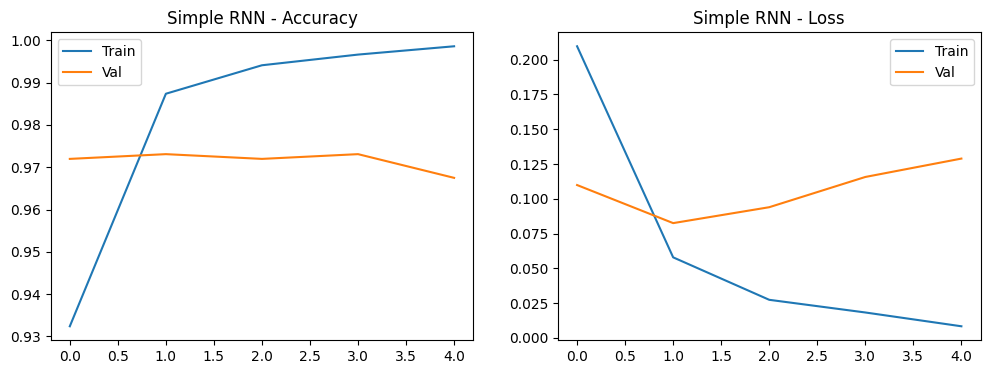

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

--- Simple RNN Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.98      0.89      0.93       150

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



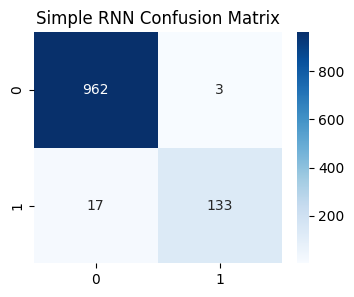

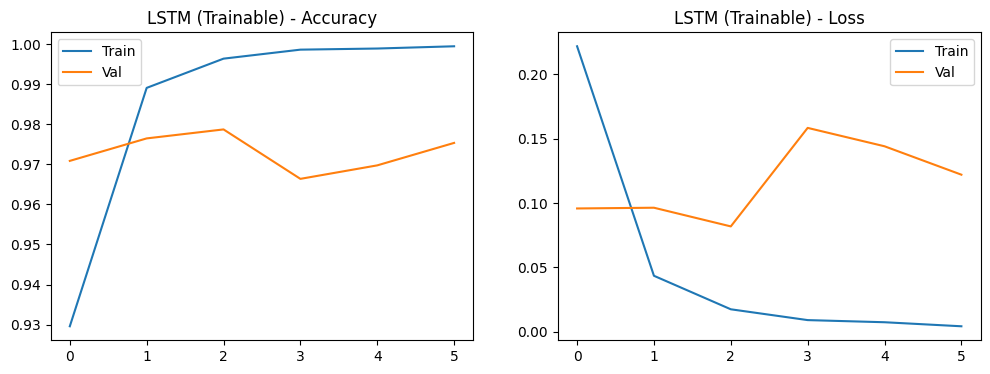

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

--- LSTM (Trainable) Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.99      0.87      0.93       150

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



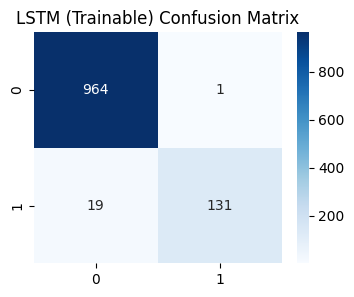

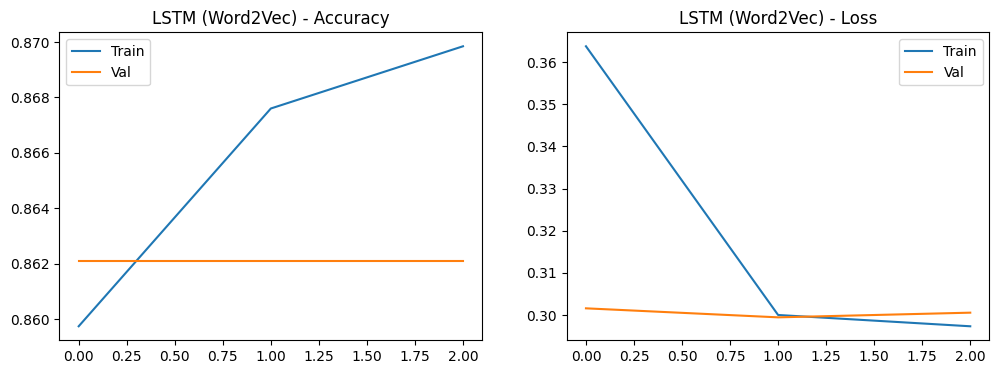

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step

--- LSTM (Word2Vec) Classification Report ---
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       965
           1       0.00      0.00      0.00       150

    accuracy                           0.87      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.75      0.87      0.80      1115



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


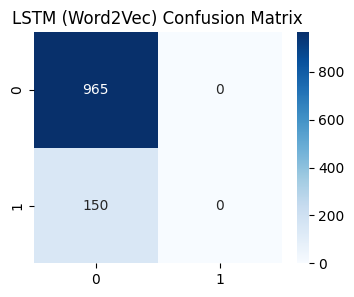

In [47]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title(f'{title} - Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.show()

def evaluate_model(model, name):
    predictions = (model.predict(X_test_pad) > 0.5).astype('int32')
    print(f'\n--- {name} Classification Report ---')
    print(classification_report(y_test, predictions))
    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.show()

plot_history(history1, 'Simple RNN')
evaluate_model(model1, 'Simple RNN')

plot_history(history2, 'LSTM (Trainable)')
evaluate_model(model2, 'LSTM (Trainable)')

plot_history(history3, 'LSTM (Word2Vec)')
evaluate_model(model3, 'LSTM (Word2Vec)')

### 4.5.2 Model 3: LSTM with Pretrained Word2Vec Embeddings
We train a Word2Vec model on our corpus to create an embedding matrix, which is then used as static weights for our third model.

In [48]:
from gensim.models import Word2Vec

# Prepare tokens for Word2Vec training
sentences = [text.split() for text in X_train_raw]

# Train Word2Vec model
w2v_model = Word2Vec(sentences, vector_size=embedding_dim, window=5, min_count=1, workers=4)

# Create embedding matrix
vocab_size_w2v = min(max_words, len(tokenizer.word_index) + 1)
embedding_matrix = np.zeros((vocab_size_w2v, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i < vocab_size_w2v:
        if word in w2v_model.wv:
            embedding_matrix[i] = w2v_model.wv[word]

# Model 3: LSTM using Word2Vec embeddings
model3 = Sequential([
    Embedding(input_dim=vocab_size_w2v, output_dim=embedding_dim, weights=[embedding_matrix], input_length=max_pad_length, trainable=False),
    LSTM(64),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print('Training Model 3 (LSTM with Word2Vec)...')
history3 = model3.fit(X_train_pad, y_train, epochs=10, batch_size=32, validation_split=0.2, callbacks=[early_stop], verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Training Model 3 (LSTM with Word2Vec)...
Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.8651 - loss: 0.3701 - val_accuracy: 0.8621 - val_loss: 0.3077
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.8684 - loss: 0.2963 - val_accuracy: 0.8621 - val_loss: 0.3003
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.8684 - loss: 0.2951 - val_accuracy: 0.8666 - val_loss: 0.2989


### 4.5.3 Model Training and Evaluation
Visualization of training history and final evaluation using Confusion Matrices and Classification Reports.

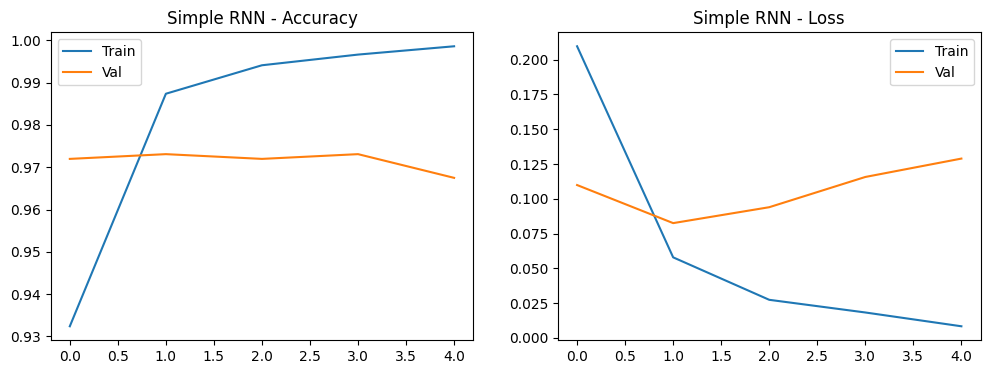

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

--- Simple RNN Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.98      0.89      0.93       150

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



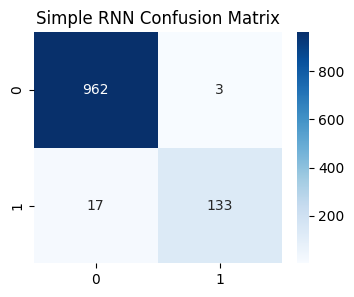

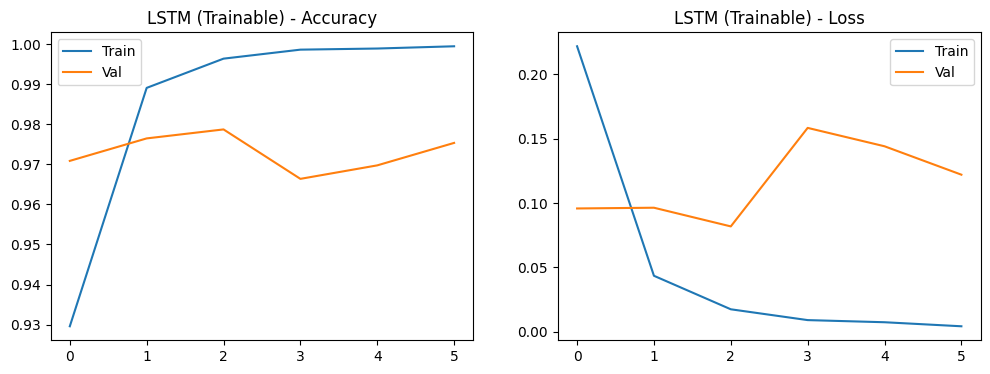

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

--- LSTM (Trainable) Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.99      0.87      0.93       150

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



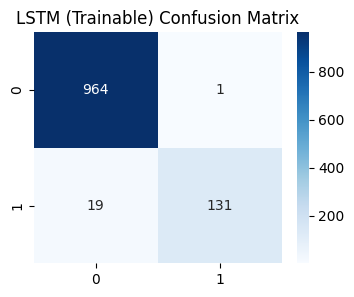

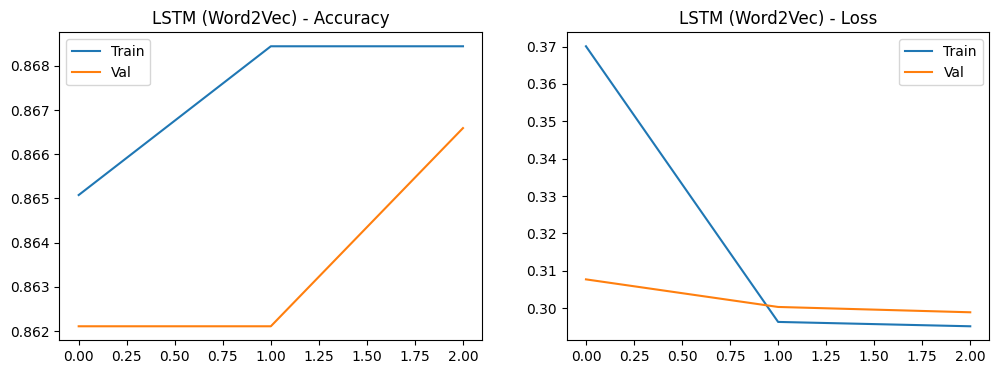

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step

--- LSTM (Word2Vec) Classification Report ---
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       965
           1       0.00      0.00      0.00       150

    accuracy                           0.87      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.75      0.87      0.80      1115



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


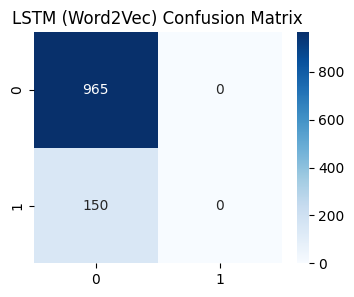

In [49]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title(f'{title} - Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.show()

def evaluate_model(model, name):
    predictions = (model.predict(X_test_pad) > 0.5).astype('int32')
    print(f'\n--- {name} Classification Report ---')
    print(classification_report(y_test, predictions))
    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.show()

plot_history(history1, 'Simple RNN')
evaluate_model(model1, 'Simple RNN')

plot_history(history2, 'LSTM (Trainable)')
evaluate_model(model2, 'LSTM (Trainable)')

plot_history(history3, 'LSTM (Word2Vec)')
evaluate_model(model3, 'LSTM (Word2Vec)')

### 4.5.2 Model 3: LSTM with Pretrained Word2Vec Embeddings
We will train a Word2Vec model on our training data to create custom word embeddings and then use them in an LSTM architecture.

In [50]:
from gensim.models import Word2Vec

# Prepare sentences for Word2Vec
sentences = [text.split() for text in X_train_raw]

# Train Word2Vec model
w2v_model = Word2Vec(sentences, vector_size=embedding_dim, window=5, min_count=1, workers=4)

# Create an embedding matrix
vocab_size_w2v = min(max_words, len(tokenizer.word_index) + 1)
embedding_matrix = np.zeros((vocab_size_w2v, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i < max_words:
        if word in w2v_model.wv:
            embedding_matrix[i] = w2v_model.wv[word]

# Model 3: LSTM with Word2Vec
model3 = Sequential([
    Embedding(input_dim=vocab_size_w2v,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              input_length=max_pad_length,
              trainable=False),
    LSTM(64),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training Model 3 (LSTM with Word2Vec)...")
history3 = model3.fit(X_train_pad, y_train, epochs=10, batch_size=32, validation_split=0.2, callbacks=[early_stop], verbose=1)

Training Model 3 (LSTM with Word2Vec)...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.8592 - loss: 0.3753 - val_accuracy: 0.8621 - val_loss: 0.3047
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8654 - loss: 0.2994 - val_accuracy: 0.8621 - val_loss: 0.2996
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8617 - loss: 0.3011 - val_accuracy: 0.8621 - val_loss: 0.2988


### 4.5.3 Visualization and Evaluation
Comparing the performance of all three models using accuracy, loss plots, and classification reports.

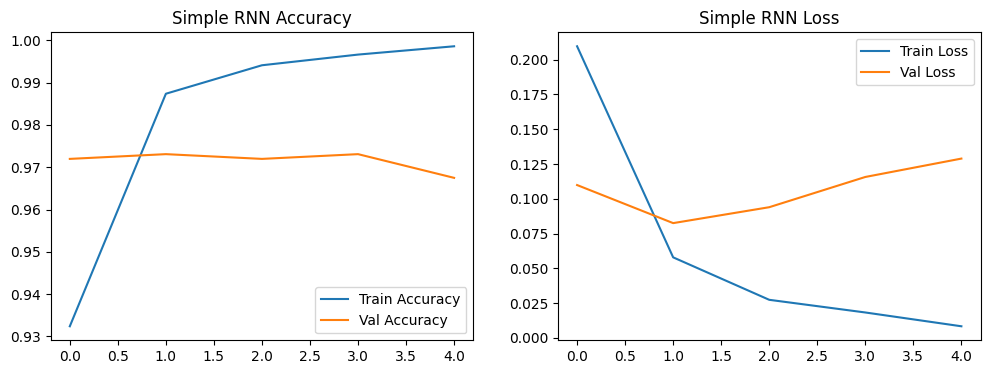

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

--- Simple RNN Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.98      0.89      0.93       150

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



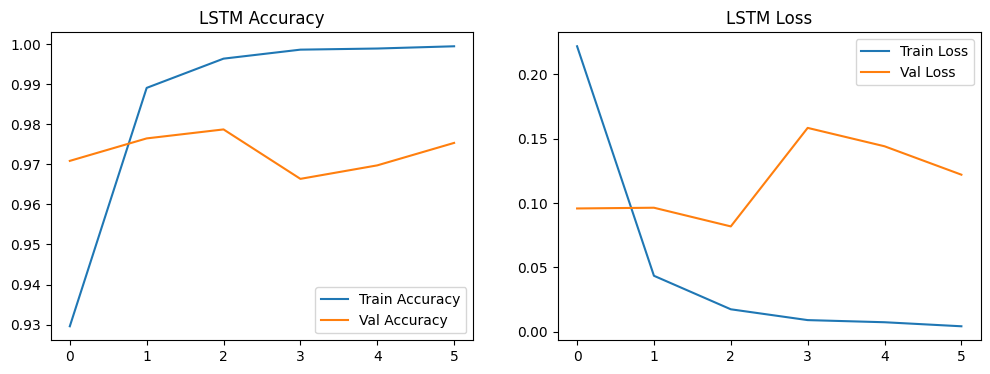

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

--- LSTM Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.99      0.87      0.93       150

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



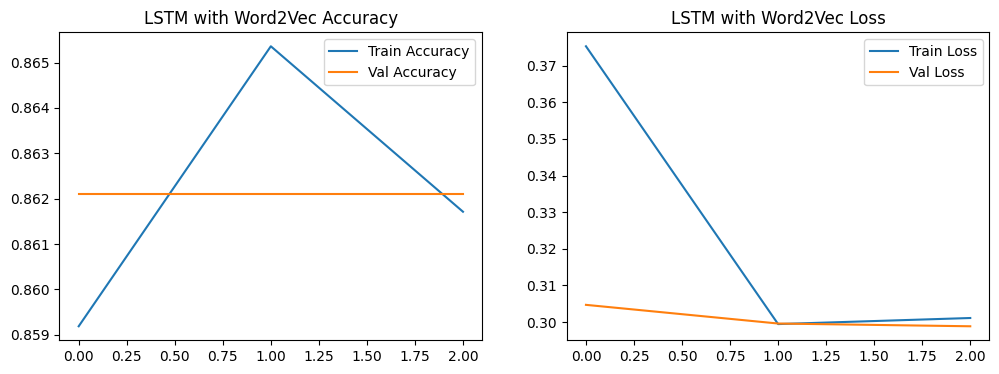

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

--- LSTM with Word2Vec Classification Report ---
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       965
           1       0.00      0.00      0.00       150

    accuracy                           0.87      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.75      0.87      0.80      1115



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [51]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_and_plot(model, history, name):
    # Plot Training vs Validation Loss
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{name} Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{name} Loss')
    plt.legend()
    plt.show()

    # Evaluation
    y_pred = (model.predict(X_test_pad) > 0.5).astype("int32")
    print(f"\n--- {name} Classification Report ---")
    print(classification_report(y_test, y_pred))

evaluate_and_plot(model1, history1, "Simple RNN")
evaluate_and_plot(model2, history2, "LSTM")
evaluate_and_plot(model3, history3, "LSTM with Word2Vec")

### 4.5.2 & 4.5.3 Model Building, Training, and Evaluation
We will now construct the Simple RNN and LSTM models, then train them using early stopping to prevent overfitting.

In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

vocab_size = 10000
embedding_dim = 64
# Use the max_pad_length calculated in the previous cell
try:
    input_length = max_pad_length
except NameError:
    input_length = 50 # Fallback if not defined

# Model 1: Simple RNN
model1 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=input_length),
    SimpleRNN(64),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Model 2: LSTM
model2 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=input_length),
    LSTM(64),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Training Model 1 (Simple RNN)...")
history1 = model1.fit(X_train_pad, y_train, epochs=10, validation_split=0.2, callbacks=[early_stop], verbose=1)

print("\nTraining Model 2 (LSTM)...")
history2 = model2.fit(X_train_pad, y_train, epochs=10, validation_split=0.2, callbacks=[early_stop], verbose=1)

Training Model 1 (Simple RNN)...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9366 - loss: 0.1715 - val_accuracy: 0.9709 - val_loss: 0.0948
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9874 - loss: 0.0493 - val_accuracy: 0.9697 - val_loss: 0.0955
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9950 - loss: 0.0199 - val_accuracy: 0.9641 - val_loss: 0.1020
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9972 - loss: 0.0127 - val_accuracy: 0.9709 - val_loss: 0.1103

Training Model 2 (LSTM)...
Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9254 - loss: 0.2221 - val_accuracy: 0.9765 - val_loss: 0.0842
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9885 - loss: 0.0412 - val_accuracy: 0.9765 - val_loss: 0.0720
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9972 - loss: 0.0152 - val_accuracy: 0.9697 - val_loss: 0.1290
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9964 - loss: 

### 4.5.2 & 4.5.3 Model Building, Training, and Evaluation
We will now construct the Simple RNN and LSTM models, then train them using early stopping to prevent overfitting.

In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

vocab_size = max_words
embedding_dim = 64
input_length = max_pad_length

# Model 1: Simple RNN
model1 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=input_length),
    SimpleRNN(64),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Model 2: LSTM
model2 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=input_length),
    LSTM(64),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Training Model 1 (Simple RNN)...")
history1 = model1.fit(X_train_pad, y_train, epochs=10, validation_split=0.2, callbacks=[early_stop], verbose=1)

print("\nTraining Model 2 (LSTM)...")
history2 = model2.fit(X_train_pad, y_train, epochs=10, validation_split=0.2, callbacks=[early_stop], verbose=1)

Training Model 1 (Simple RNN)...
Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9461 - loss: 0.1582 - val_accuracy: 0.9742 - val_loss: 0.0954
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9863 - loss: 0.0471 - val_accuracy: 0.9697 - val_loss: 0.1061
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9961 - loss: 0.0166 - val_accuracy: 0.9742 - val_loss: 0.1154
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9966 - loss: 0.0156 - val_accuracy: 0.9709 - val_loss: 0.1162

Training Model 2 (LSTM)...
Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9268 - loss: 0.2172 - val_accuracy: 0.9742 - val_loss: 0.0885
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9877 - loss: 0.0462 - val_accuracy: 0.9686 - val_loss: 0.1453
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9902 - loss: 0.0453 - val_accuracy: 0.9720 - val_loss: 0.1166
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━